In [70]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sristivats1006/assignment/headbrain.csv
/kaggle/input/datasets/sristivats1006/assignment/titanic.csv
/kaggle/input/datasets/sristivats1006/assignment/diabetes.csv


# **Exercise 1:Linear and Logistic Regression with Error Estimation**

### Setup check

In [71]:
import os
import sys

print("Python", sys.version.split()[0])

for package in ["numpy", "pandas", "matplotlib", "seaborn", "sklearn"]:
    try:
        __import__(package)
        print(f"{package:<12} found")
    except ImportError:
        print(f"{package:<12} MISSING  ->  pip install {package}")

DATA_DIR = "/kaggle/input/datasets/sristivats1006/assignment"

for filename in ["headbrain.csv", "titanic.csv", "diabetes.csv"]:
    path = os.path.join(DATA_DIR, filename)
    status = "found" if os.path.isfile(path) else "MISSING"
    print(f"{filename:<16} {status}")

Python 3.12.13
numpy        found
pandas       found
matplotlib   found
seaborn      found
sklearn      found
headbrain.csv    found
titanic.csv      found
diabetes.csv     found


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Part A. Linear regression

## Program 1. Ordinary least squares regression, from first principles and with `scikit-learn`

### Theory

The regression line is written as $y = b_0 + b_1 x$. The least squares estimates of the two
coefficients are

$$
\newcommand{\vect}{\mathbf}
\begin{align}
b_1 &= \frac{\displaystyle \sum_{i=1}^{m}(x_i-\bar{x})(y_i-\bar{y})}{\displaystyle \sum_{i=1}^{m}(x_i-\bar{x})^2}
= \frac{(\vect{x}-\bar{x})^T(\vect{y}-\bar{y})}{(\vect{x}-\bar{x})^T(\vect{x}-\bar{x})}
\\
b_0 &= \bar{y}-b_1\bar{x}
\end{align}
$$

The quality of the fit is summarised by

$$
\begin{align}
\text{RMSE} &= \sqrt{\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat{y_i})^2}
= \sqrt{\frac{(\vect{y}-\hat{\vect{y}})^T(\vect{y}-\hat{\vect{y}})}{m}}
\\
\text{SS}_{\text{tot}} &= \sum_{i=1}^{m}(y_i - \bar{y})^2 = (\vect{y}-\bar{y})^T(\vect{y}-\bar{y})
\\
\text{SS}_{\text{res}} &= \sum_{i=1}^{m}(y_i - \hat{y}_i)^2 = (\vect{y}-\hat{\vect{y}})^T(\vect{y}-\hat{\vect{y}})
\\
R^{2} &= 1-\frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
\end{align}
$$

where $\vect{x} = (x_1,x_2,\dots,x_m)$ is the input vector, $\vect{y} = (y_1,y_2,\dots,y_m)$ is the
output vector, $\bar{x}$ and $\bar{y}$ are the corresponding means, and
$\hat{\vect{y}} = (\hat{y}_1,\hat{y}_2,\dots,\hat{y}_m)$ is the vector of predicted values.

Under the usual assumption of independent errors of constant variance, the standard errors of the
two coefficients follow from the residual variance
$s^2 = \text{SS}_{\text{res}}/(m-2)$:

$$
\begin{align}
\text{SE}(b_1) &= \sqrt{\frac{s^2}{\sum_{i=1}^{m}(x_i-\bar{x})^2}}
\\
\text{SE}(b_0) &= \sqrt{s^2\left[\frac{1}{m} + \frac{\bar{x}^2}{\sum_{i=1}^{m}(x_i-\bar{x})^2}\right]}
\end{align}
$$

The divisor $m-2$ appears because two parameters have already been estimated from the same data.

### TASK A1. Implementing the regression class

In [73]:
class LinearRegression:
    """Simple linear regression by ordinary least squares."""

    def fit(self, X, y):
        m = X.shape[0]

        x_mean = X.mean()
        y_mean = y.mean()

        x_c = X - x_mean
        y_c = y - y_mean

        self.b1 = (x_c @ y_c) / (x_c @ x_c)
        self.b0 = y_mean - self.b1 * x_mean

        print(f"(b0, b1) = ({self.b0:.3f}, {self.b1:.3f})")
        return self

    def predict(self, X):
        return self.b0 + self.b1 * X

    def evaluate(self, X, y):
        y_pred = self.predict(X)

        ss_res = ((y - y_pred) ** 2).sum()
        ss_tot = ((y - y.mean()) ** 2).sum()
        rmse = np.sqrt(ss_res / len(y))
        r2 = 1 - ss_res / ss_tot

        print("Root mean squared error:", round(rmse, 3))
        print("R^2 value:", round(r2, 3))
        return rmse, r2

### TASK A2. Plotting the fit

In [74]:
def regression_plot(X, y, model, title=""):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Head size (cm^3)")
    plt.ylabel("Brain weight (grams)")

    x_line = np.array([X.min() - 1, X.max() + 1]).reshape(-1, 1)
    y_line = model.predict(x_line)

    plt.scatter(X, y, label="Observed data", alpha=0.6)
    plt.plot(x_line, y_line, color="red", label="Fitted line")
    plt.legend()
    plt.show()

### TASK A3. Fitting the head and brain dataset

In [75]:
# load
data = pd.read_csv("/kaggle/input/datasets/sristivats1006/assignment/headbrain.csv")
print(data.shape)
data.head()

(237, 4)


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [76]:
X = data["Head Size(cm^3)"].values
y = data["Brain Weight(grams)"].values

(b0, b1) = (325.573, 0.263)


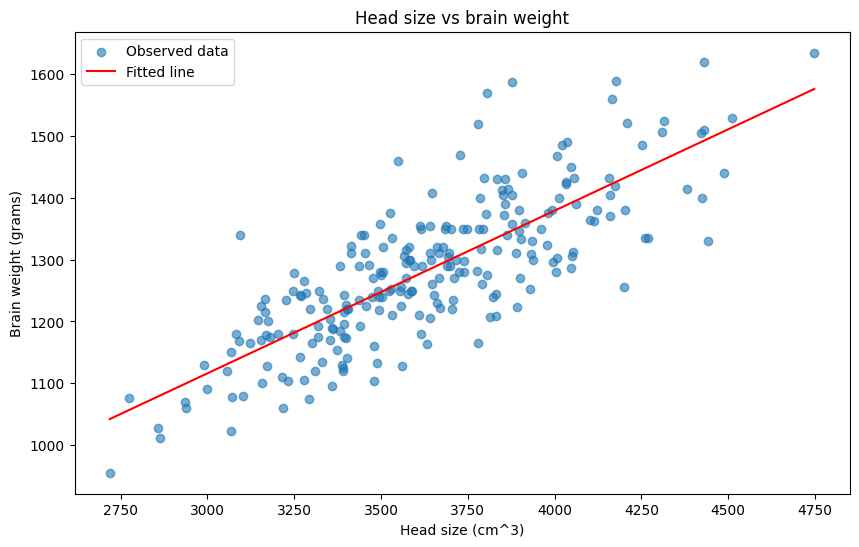

Root mean squared error: 72.121
R^2 value: 0.639


(np.float64(72.1206213783709), np.float64(0.639311719957))

In [77]:
model = LinearRegression()
model.fit(X, y)
regression_plot(X, y, model, title="Head size vs brain weight")
model.evaluate(X, y)

### TASK A4. Comparison with `scikit-learn`

In [78]:
from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.metrics import mean_squared_error

X1 = X.reshape(-1, 1)

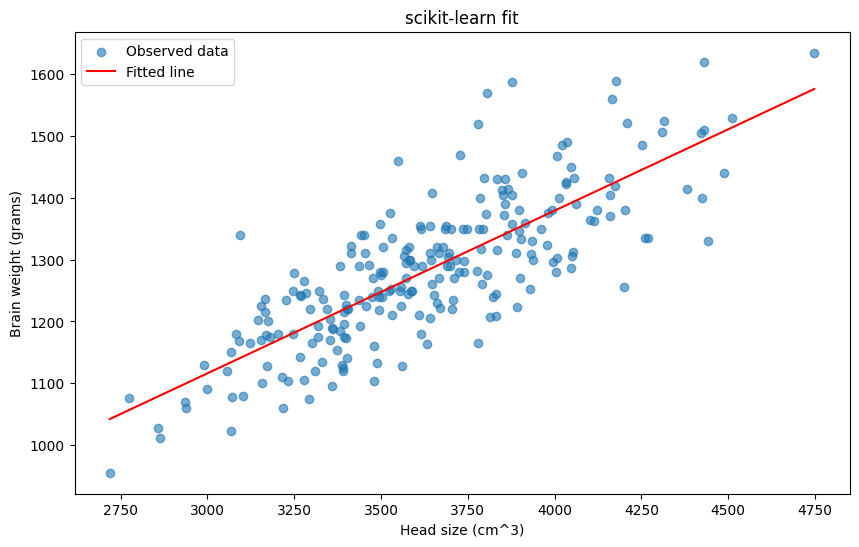

Intercept (b0): 325.5734210494426
Coefficient (b1): 0.26342933948939934
RMSE: 72.121
R^2: 0.639
|Δb0| = 2.2737367544323206e-13
|Δb1| = 5.551115123125783e-17


In [79]:
sk_model = SkLinearRegression()
sk_model.fit(X1, y)

regression_plot(X, y, sk_model, title="scikit-learn fit")

y_pred = sk_model.predict(X1)
rmse_sk = np.sqrt(mean_squared_error(y, y_pred))
r2_sk = sk_model.score(X1, y)

print("Intercept (b0):", sk_model.intercept_)
print("Coefficient (b1):", sk_model.coef_[0])
print("RMSE:", round(rmse_sk, 3))
print("R^2:", round(r2_sk, 3))

print("|Δb0| =", abs(model.b0 - sk_model.intercept_))
print("|Δb1| =", abs(model.b1 - sk_model.coef_[0]))

### TASK A5. Error estimation

In [80]:
def coefficient_standard_errors(X, y, model):
    m = X.shape[0]
    residuals = y - model.predict(X)
    s2 = (residuals @ residuals) / (m - 2)

    x_c = X - X.mean()
    sxx = x_c @ x_c

    se_b1 = np.sqrt(s2 / sxx)
    se_b0 = np.sqrt(s2 * (1 / m + X.mean()**2 / sxx))
    return se_b0, se_b1


se_b0, se_b1 = coefficient_standard_errors(X, y, model)
ci_b0 = 1.96 * se_b0
ci_b1 = 1.96 * se_b1

print(f"b0 = {model.b0:.3f} +/- {ci_b0:.3f}  (SE = {se_b0:.3f})")
print(f"b1 = {model.b1:.3f} +/- {ci_b1:.3f}  (SE = {se_b1:.3f})")

b0 = 325.573 +/- 92.396  (SE = 47.141)
b1 = 0.263 +/- 0.025  (SE = 0.013)


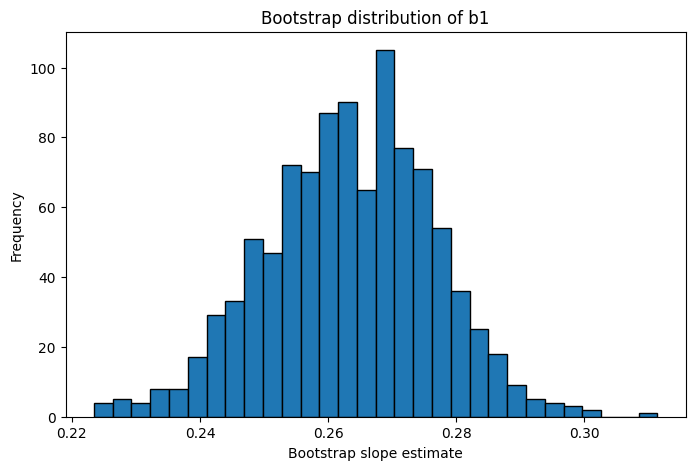

Bootstrap SD of b1: 0.013153558749129645
Analytical SE(b1): 0.012907433440886974


In [81]:
def bootstrap_slope(X, y, n_resamples=1000, seed=0):
    rng = np.random.default_rng(seed)
    m = X.shape[0]
    slopes = np.empty(n_resamples)

    for i in range(n_resamples):
        idx = rng.integers(0, m, size=m)
        boot_model = LinearRegression()
        boot_model.b1 = None  # suppress nothing, just refit
        # avoid printing during bootstrap:
        x_c = X[idx] - X[idx].mean()
        y_c = y[idx] - y[idx].mean()
        slopes[i] = (x_c @ y_c) / (x_c @ x_c)

    return slopes


slopes = bootstrap_slope(X, y)
plt.figure(figsize=(8, 5))
plt.hist(slopes, bins=30, edgecolor="k")
plt.xlabel("Bootstrap slope estimate")
plt.ylabel("Frequency")
plt.title("Bootstrap distribution of b1")
plt.show()

print("Bootstrap SD of b1:", slopes.std())
print("Analytical SE(b1):", se_b1)

Comment: the bootstrap SD and the analytical SE should be very close (typically within a few percent), which confirms the constant-variance assumption behind the analytical formula is reasonable for this dataset.

TASK A6. Written questions
1. Units of 𝑏1: grams per cm³ (since y is in grams,x in cm³). It means: for each additional cm³ of head size, brain weight increases by b1(i.e. 0.263) grams on average.
2. Two reasons R^2 isn't near 1: (a) brain weight depends on other factors too — age, sex, overall body size — not captured by head size alone; (b) measurement noise/biological variability means even a perfect linear relationship wouldn't explain 100% of variance.
3. If head size were in m³ instead of cm³ (𝑥𝑛𝑒𝑤= 𝑥/10^6 :b1 scales up by 10^6(since y= b0+b1x =
b0+(b1 * 10^6)xnew), b0 is unchanged, and RMSE and R^2 are both unchanged (they depend only on residuals in y, and y wasn't rescaled).In short, only the slope's numerical value and units change; the fit itself is identical.

# Part B. Logistic regression

## Program 1. Preprocessing and classification on the Titanic dataset with `scikit-learn`

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic_df = pd.read_csv("/kaggle/input/datasets/sristivats1006/assignment/titanic.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### TASK B1. Exploratory visualisation

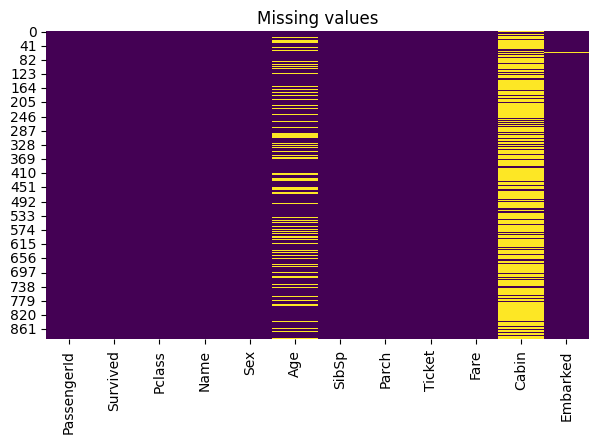

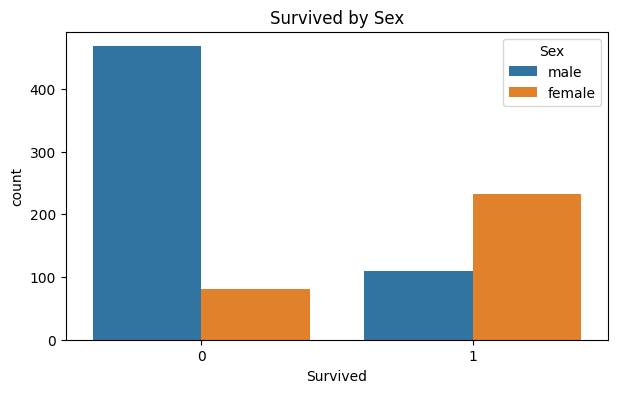

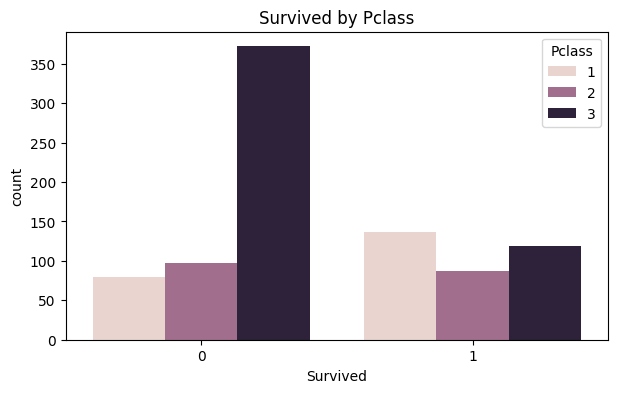

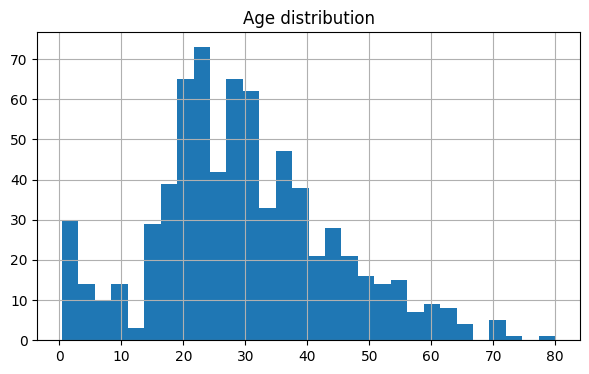

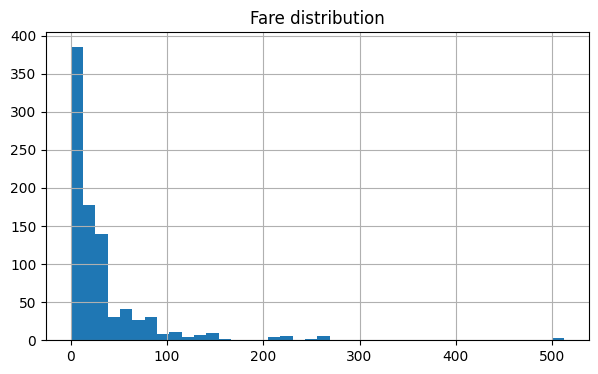

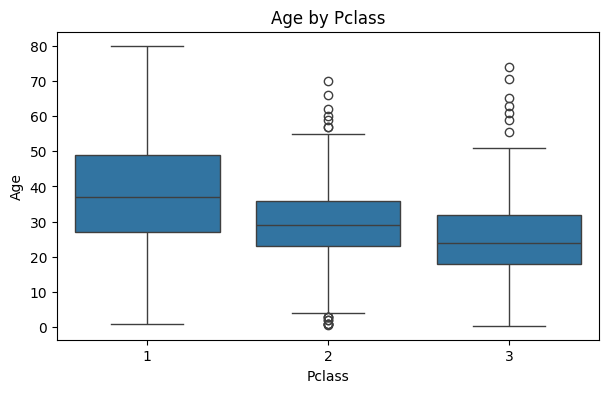

In [83]:
def plot(title, plot_func, *args, **kwargs):
    plt.figure(figsize=(7, 4))
    plt.title(title)
    plot_func(*args, **kwargs)
    plt.show()
plot("Missing values", sns.heatmap, titanic_df.isnull(), cbar=False, cmap="viridis")
plot("Survived by Sex", sns.countplot, x="Survived", hue="Sex", data=titanic_df)
plot("Survived by Pclass", sns.countplot, x="Survived", hue="Pclass", data=titanic_df)
plot("Age distribution", lambda **kw: titanic_df["Age"].dropna().hist(**kw), bins=30)
plot("Fare distribution", lambda **kw: titanic_df["Fare"].hist(**kw), bins=40)
plot("Age by Pclass", sns.boxplot, x="Pclass", y="Age", data=titanic_df)

Answer B1: Age, Cabin, and Embarked carry missing values (visible as pale streaks in the heatmap). The box plot typically shows that median age decreases from 1st to 3rd class - wealthier (1st class) passengers tend to be older, which is exactly why imputing age by class mean (next task) makes more sense than a single overall mean.

### TASK B2. Missing, categorical, and irrelevant columns

In [84]:
mean_ages = titanic_df.groupby("Pclass")["Age"].mean().to_dict()


def impute_missing_age(columns):
    age, p_class = columns
    if pd.isnull(age):
        return mean_ages[p_class]
    return age


titanic_df["Age"] = titanic_df[["Age", "Pclass"]].apply(impute_missing_age, axis=1)

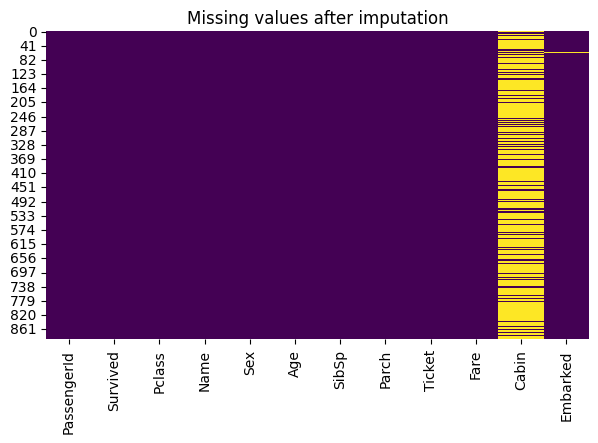

In [85]:
plot("Missing values after imputation", sns.heatmap, titanic_df.isnull(), cbar=False, cmap="viridis")

In [86]:
titanic_df.drop("Cabin", axis=1, inplace=True)
titanic_df.dropna(inplace=True)

sex = pd.get_dummies(titanic_df["Sex"], drop_first=True)
embarked = pd.get_dummies(titanic_df["Embarked"], drop_first=True)
titanic_df = pd.concat([titanic_df, sex, embarked], axis=1)

titanic_df.drop(["Name", "PassengerId", "Ticket", "Sex", "Embarked"], axis=1, inplace=True)
titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


Answer B2: drop_first=True drops one category (e.g. "female" for Sex, one port for Embarked) because it's redundant — it's fully determined by the other dummy columns (if male=0 then it must be female). Keeping all indicator columns creates perfect multicollinearity (the "dummy variable trap"), which makes the design matrix singular/near-singular and destabilizes coefficient estimation.

### TASK B3. Fitting and evaluating the classifier

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import minmax_scale

titanic_df["Age"] = minmax_scale(titanic_df["Age"])
titanic_df["Fare"] = minmax_scale(titanic_df["Fare"])

X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       167
           1       0.72      0.72      0.72       100

    accuracy                           0.79       267
   macro avg       0.78      0.78      0.78       267
weighted avg       0.79      0.79      0.79       267

[[139  28]
 [ 28  72]]


### TASK B4. Interpretation

1.Label the 2×2 confusion_matrix output as: top-left = true negatives (predicted 0, actual 0), top-right = false positives, bottom-left = false negatives, bottom-right = true positives (predicted 1, actual 1) — using "survived" as the positive class.
Top-left = 139 → True Negatives (TN): predicted did not survive, actually did not survive
Top-right = 28 → False Positives (FP): predicted survived, actually did not survive
Bottom-left = 28 → False Negatives (FN): predicted did not survive, actually survived
Bottom-right = 72 → True Positives (TP): predicted survived, actually survived

2.Precision is the reliability of a positive prediction: of all the passengers the model claimed would survive, the fraction that actually did. Recall (sensitivity) is the coverage of the positive class: of all the passengers who actually survived, the fraction the model successfully found. Precision = TP/(TP+FP) = 72/(72+28) = 72/100 = 0.72
Recall = TP/(TP+FN) = 72/(72+28) = 72/100 = 0.72. Both match the classification report's row for class 1 exactly (0.72 / 0.72, F1 = 0.72).Both values are 0.72, matching the class-1 row of the classification report — confirming the hand calculation is consistent with sklearn's own computation.

3.in next cell
1 0.824
42 0.79
100 0.783

In [88]:
for rs in [1, 42, 100]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=rs)
    m = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    acc = (m.predict(Xte) == yte).mean()
    print(rs, round(acc, 3))

1 0.824
42 0.79
100 0.783


## Program 2. Logistic regression by gradient descent, compared with `scikit-learn`


### Theory

$$
\newcommand{\vect}{\mathbf}
\text{Log-likelihood}, \quad LL = \sum_{i=1}^{m} y_i \log(p_i) + (1-y_i)\log(1-p_i)
$$

where

$$
p_i = p(\vect{x}_i, \vect{w}) = \frac{1}{1+e^{-\vect{w}^T\vect{x}_i}}
$$

Here $\vect{w} = (w_0, w_1, \dots, w_n)$ is the weight vector and
$\vect{x}_i = (1, x_{i1}, x_{i2}, \dots, x_{in})$ is the $i$th input vector, the leading unit
entry accounting for the intercept.

The weights are chosen so that

$$
\max_{\vect{w}} LL = \min_{\vect{w}} (-LL)
$$

The gradient of the negative log-likelihood takes the compact form

$$
\frac{d(-LL)}{d\vect{w}} = \sum_{i=1}^{m}(p_i-y_i)\,\vect{x}_i = (\vect{p}-\vect{y})^T X
$$

so that the update step of gradient descent is

$$
\vect{w} := \vect{w} - \alpha\,(\vect{p}-\vect{y})^T X
$$

where $\alpha$ is the learning rate.

### TASK B5. Implementing the classifier

In [89]:
class LogitRegression:
    """Binary logistic regression trained by full batch gradient descent."""

    def __init__(self, learning_rate, iterations):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def p(self, X):
        return 1 / (1 + np.exp(-(X @ self.w)))

    def fit(self, X, y):
        m, n = X.shape
        X = np.hstack([np.ones((m, 1)), X])
        y = y.squeeze()
        self.w = np.zeros(n + 1)
        for _ in range(self.iterations):
            self.w -= self.learning_rate * ((self.p(X) - y) @ X) / m
        return self

    def predict(self, X):
        m = X.shape[0]
        X = np.hstack([np.ones((m, 1)), X])
        return (self.p(X) >= 0.5).astype(int)

In [90]:
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

diabetes_df = pd.read_csv("/kaggle/input/datasets/sristivats1006/assignment/diabetes.csv")
X = minmax_scale(diabetes_df.iloc[:, :-1].values)
y = diabetes_df.iloc[:, -1:].values.reshape(-1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=6
)
print(X_train.shape, X_test.shape)

(512, 8) (256, 8)


In [91]:
def compute_accuracy(model, X_test, y_test):
    y_hat = model.predict(X_test)
    return (y_hat == y_test).mean() * 100


models = [
    LogitRegression(learning_rate=0.1, iterations=1000),
    LogisticRegression(),
]

for m in models:
    m.fit(X_train, y_train)
    print(type(m).__name__, "test accuracy:", round(compute_accuracy(m, X_test, y_test), 2))

LogitRegression test accuracy: 74.22
LogisticRegression test accuracy: 78.91


### TASK B6. Effect of the learning rate

In [92]:
for lr in [0.001, 0.01, 0.1, 1.0]:
    m = LogitRegression(learning_rate=lr, iterations=1000).fit(X_train, y_train)
    acc = compute_accuracy(m, X_test, y_test)
    print(f"learning_rate={lr:<6} accuracy={acc:.2f}%")

learning_rate=0.001  accuracy=67.58%
learning_rate=0.01   accuracy=67.58%
learning_rate=0.1    accuracy=74.22%
learning_rate=1.0    accuracy=77.34%


Comment: at lr=0.001 the model likely hasn't converged in only 1000 iterations, so accuracy is noticeably lower. At lr=1.0, updates may overshoot and oscillate (sometimes producing nan/instability, or just a lower/unstable accuracy). Accuracy improves as the rate rises, reaching 77.34% at 1.0, near scikit-learn's 78.91%. A much larger rate would overshoot and oscillate instead of converging.